## 1. Install Libraries

In [1]:
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 100.2 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import faiss
import umap.umap_ as umap

from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

tqdm.pandas()

## 3. Project Paths

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/FinSight_AI"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data"
)

PROCESSED_PATH = os.path.join(
    DATA_PATH,
    "processed"
)

EMBEDDING_PATH = os.path.join(
    DATA_PATH,
    "embeddings"
)

REPORT_PATH = os.path.join(
    PROJECT_PATH,
    "reports"
)

os.makedirs(
    EMBEDDING_PATH,
    exist_ok=True
)

os.makedirs(
    REPORT_PATH,
    exist_ok=True
)

## 4. Load Dataset

In [4]:
news_df = pd.read_parquet(

    os.path.join(

        PROCESSED_PATH,

        "financial_news_clean.parquet"

    )

)

In [5]:
print(news_df.shape)

news_df.head()

(3215296, 18)


,news_id,headline,url,publisher,published_date,ticker,source,year,month,day,weekday,hour,headline_length,word_count,has_time,original_headline,clean_character_count,clean_word_count
0,1,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,analyst,2020,6,5,Friday,14,39,7,True,Stocks That Hit 52-Week Highs On Friday,39,7
1,2,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,analyst,2020,6,3,Wednesday,14,42,7,True,Stocks That Hit 52-Week Highs On Wednesday,42,7
2,3,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,analyst,2020,5,26,Tuesday,8,29,5,True,71 Biggest Movers From Friday,29,5
3,4,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,analyst,2020,5,22,Friday,16,44,7,True,46 Stocks Moving In Friday's Mid-Day Session,44,7
4,5,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,analyst,2020,5,22,Friday,15,87,14,True,B of A Securities Maintains Neutral on Agilent...,87,14


## 5. Device

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


## 6. Load Embedding Model

#### using BAAI/bge-base-en-v1.5.

In [7]:
embedding_model = SentenceTransformer(

    "BAAI/bge-base-en-v1.5",

    device=device

)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
embedding_model

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'cls', 'include_prompt': True})
  (2): Normalize({})
)

## 7. Model Information

In [9]:
print(

    embedding_model.get_sentence_embedding_dimension()

)

768


## 8. Create Sample Dataset

In [10]:
sample_df = news_df.sample(

    n=100,

    random_state=42

).reset_index(drop=True)

In [11]:
sample_df.head()

,news_id,headline,url,publisher,published_date,ticker,source,year,month,day,weekday,hour,headline_length,word_count,has_time,original_headline,clean_character_count,clean_word_count
0,66764,Antero Midstream shares are trading lower afte...,https://www.benzinga.com/markets/wiim/19/11/14...,Benzinga Newsdesk,2019-11-07 00:00:00+00:00,AM,analyst,2019,11,7,Thursday,0,242,39,True,Antero Midstream shares are trading lower afte...,242,39
1,1666858,Cnooc's Nexen cutting 340 jobs in North Americ...,http://seekingalpha.com/news/2374556-cnoocs-ne...,Seeking Alpha,2015-03-17 00:00:00+00:00,CEO,partner,2015,3,17,Tuesday,0,73,13,False,Cnooc's Nexen cutting 340 jobs in North Americ...,73,13
2,2344335,Valuation Dashboard: Energy And Materials - Up...,http://seekingalpha.com/article/3770806-valuat...,Seeking Alpha,2015-12-22 00:00:00+00:00,KS,partner,2015,12,22,Tuesday,0,50,7,False,Valuation Dashboard: Energy And Materials - Up...,50,7
3,2050800,China Faces Tough Decisions Ahead,http://seekingalpha.com/article/4031525-china-...,Seeking Alpha,2016-12-19 00:00:00+00:00,FXP,partner,2016,12,19,Monday,0,33,5,False,China Faces Tough Decisions Ahead,33,5
4,1549634,Dividend Challenger Highlights: Week Of May 26,https://seekingalpha.com/article/4266482-divid...,Seeking Alpha,2019-05-25 00:00:00+00:00,AYR,partner,2019,5,25,Saturday,0,46,7,False,Dividend Challenger Highlights: Week Of May 26,46,7


## 9. Headlines

In [12]:
headlines = sample_df["headline"].tolist()

In [13]:
headlines[:5]

['Antero Midstream shares are trading lower after the company reported a ~25.965 million share common stock offering. Wells Fargo also downgraded the stock from Outperform to Market Perform and lowered the price target from $10 to $8 per share.',
 "Cnooc's Nexen cutting 340 jobs in North America due to oil price collapse",
 'Valuation Dashboard: Energy And Materials - Update',
 'China Faces Tough Decisions Ahead',
 'Dividend Challenger Highlights: Week Of May 26']

## 10. Generate Sentence Embeddings

In [14]:
embeddings = embedding_model.encode(

    headlines,

    batch_size=32,

    show_progress_bar=True,

    convert_to_numpy=True,

    normalize_embeddings=True

)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## 11. Check Embedding Shape

In [15]:
print("Embedding Shape :", embeddings.shape)

Embedding Shape : (100, 768)


## 12. Check Data Type

In [16]:
print("Data Type :", embeddings.dtype)

Data Type : float32


## 13. Inspect First Embedding

In [17]:
embeddings[0]

array([-6.30997792e-02, -2.48800740e-02, -1.40856125e-03,  3.76466848e-02,
        4.25316580e-02,  1.49396071e-02,  4.50846553e-02,  5.66273928e-02,
        3.86359319e-02, -3.75664495e-02,  9.36783254e-02,  1.36614952e-03,
       -2.26691011e-02,  4.48785983e-02,  3.71124446e-02,  6.88045193e-03,
        3.28716002e-02,  1.27547625e-02,  3.64225991e-02, -7.42174964e-03,
       -3.51008885e-02, -4.14895788e-02,  3.29472609e-02,  2.76262145e-02,
        7.84761366e-03, -9.25202109e-03,  1.82366520e-02, -4.60822508e-03,
       -2.37274310e-03,  9.18263476e-03,  5.89425229e-02,  1.23948874e-02,
        8.22725147e-03,  3.95502672e-02,  7.01824715e-03,  1.94599433e-03,
       -4.13443055e-03,  9.49178636e-03, -6.62410352e-03,  1.66315101e-02,
       -7.56423101e-02, -2.87368987e-02, -8.01105425e-03,  5.20453379e-02,
       -1.37244090e-02, -2.54556481e-02,  2.77289771e-03, -3.32548581e-02,
       -4.88075912e-02, -2.91696228e-02, -6.31848425e-02, -1.82696711e-02,
        6.82553556e-03, -

## 14. Add Embeddings to Sample Dataset

In [18]:
sample_df["embedding"] = embeddings.tolist()

In [19]:
sample_df[
    [
        "headline",
        "embedding"
    ]
].head()

,headline,embedding
0,Antero Midstream shares are trading lower afte...,"[-0.06309977918863297, -0.024880073964595795, ..."
1,Cnooc's Nexen cutting 340 jobs in North Americ...,"[-0.07426875084638596, -0.03965485841035843, 0..."
2,Valuation Dashboard: Energy And Materials - Up...,"[0.004846389405429363, -0.01813158206641674, 0..."
3,China Faces Tough Decisions Ahead,"[-0.03429524600505829, 0.005153581965714693, -..."
4,Dividend Challenger Highlights: Week Of May 26,"[-0.06013042852282524, -0.07978038489818573, 0..."


## 15. Check Embedding Length

In [20]:
sample_df["embedding"].apply(len).value_counts()

,count
embedding,
768,100


## 16. Basic Statistics

In [21]:
summary = pd.DataFrame({

    "Metric":[

        "Total Headlines",

        "Embedding Dimension",

        "Embedding Data Type"

    ],

    "Value":[

        len(sample_df),

        embeddings.shape[1],

        embeddings.dtype

    ]

})

summary

,Metric,Value
0,Total Headlines,100
1,Embedding Dimension,768
2,Embedding Data Type,float32


## 17. Save Sample Embeddings

In [22]:
np.save(

    os.path.join(

        EMBEDDING_PATH,

        "sample_embeddings.npy"

    ),

    embeddings

)

In [23]:
sample_df.drop(

    columns=["embedding"]

).to_parquet(

    os.path.join(

        EMBEDDING_PATH,

        "sample_embedding_metadata.parquet"

    ),

    index=False

)

## 18. Reload Test

In [24]:
loaded_embeddings = np.load(

    os.path.join(

        EMBEDDING_PATH,

        "sample_embeddings.npy"

    )

)

print(loaded_embeddings.shape)

(100, 768)


## 19. Cosine Similarity Matrix

In [25]:
similarity_matrix = cosine_similarity(
    embeddings
)

print(similarity_matrix.shape)

(100, 100)


## 20. Visualize Similarity Matrix

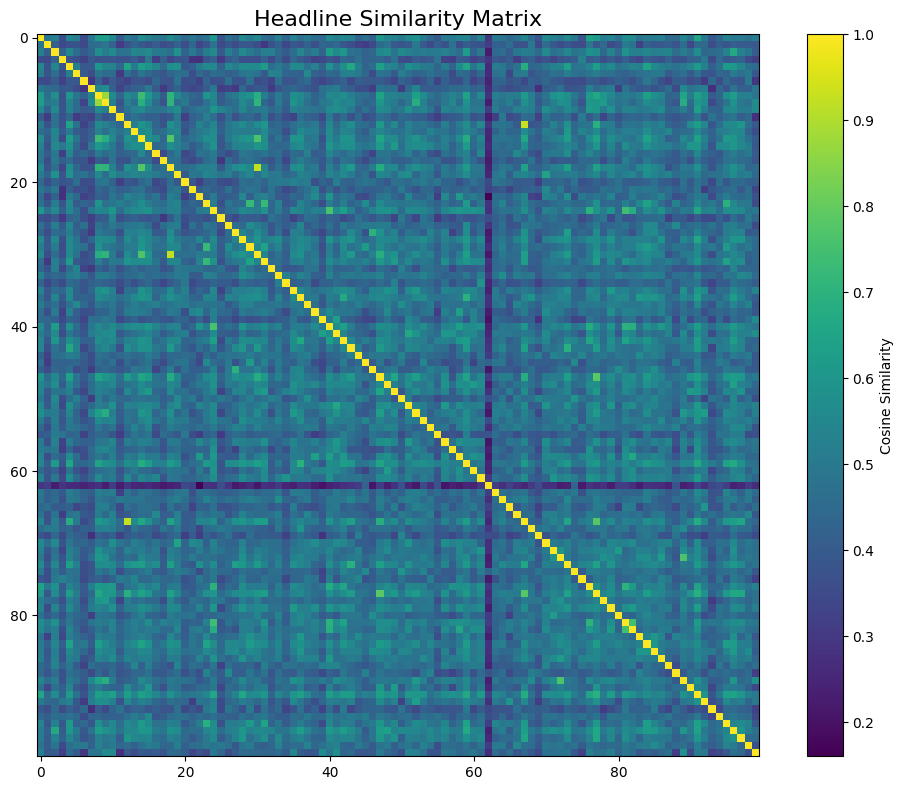

In [26]:
plt.figure(figsize=(10,8))

plt.imshow(
    similarity_matrix,
    cmap="viridis"
)

plt.colorbar(label="Cosine Similarity")

plt.title(
    "Headline Similarity Matrix",
    fontsize=16
)

plt.tight_layout()

plt.show()

## 21. Similar Headlines Function

In [27]:
def find_similar_headlines(
    query_index,
    top_k=5
):

    similarity_scores = similarity_matrix[query_index]

    ranked_indices = np.argsort(
        similarity_scores
    )[::-1]

    ranked_indices = ranked_indices[1:top_k+1]

    results = pd.DataFrame({

        "Headline":
            sample_df.loc[
                ranked_indices,
                "headline"
            ].values,

        "Similarity":
            similarity_scores[
                ranked_indices
            ]

    })

    return results

## 22. Test Similar Headlines

In [28]:
query_index = 0

print("Query Headline:\n")

print(sample_df.loc[
    query_index,
    "headline"
])

print()

find_similar_headlines(query_index)

Query Headline:

Antero Midstream shares are trading lower after the company reported a ~25.965 million share common stock offering. Wells Fargo also downgraded the stock from Outperform to Market Perform and lowered the price target from $10 to $8 per share.



,Headline,Similarity
0,Option Alert: FLR Aug16 50.0 Calls: 500 @ ASK ...,0.652893
1,Xerox Corporation Lowers FY2014 EPS Guidance f...,0.647586
2,"Benzinga's Top Upgrades, Downgrades For Februa...",0.629755
3,Benzinga's Top Downgrades,0.628410
4,65 Stocks Moving In Thursday's Mid-Day Session,0.612061


## 23. Try Multiple Headlines

In [29]:
for idx in [5, 15, 25]:

    print("="*100)

    print("Query:")

    print(sample_df.loc[idx, "headline"])

    print()

    display(

        find_similar_headlines(
            idx,
            top_k=5
        )

    )

Query:
Regions Financial's Union Planters Preferred Funding Corp. Announces Offer to Buy Certain Outstanding Preferred Shares



,Headline,Similarity
0,Auriga Has Buy Rating On Focus Media Holding (...,0.557203
1,Bradley Radoff Reports New 9.6% Stake In Harve...,0.539745
2,Searching For Big Juicy Dividends In The USA.,0.527793
3,Deutsche Bank Earlier on Walgreens Boots Allia...,0.526564
4,Top 4 NYSE Stocks In The Industrial Equipment ...,0.524360


Query:
Silver – The Bull Market Ahead



,Headline,Similarity
0,23 Stocks Moving In Friday's Pre-Market Session,0.624825
1,Market Volatility Bulletin: Product Highlight ...,0.621233
2,Market Not Worried About Taper - Ahead of Wall...,0.616666
3,"Benzinga's Top Upgrades, Downgrades For Februa...",0.608386
4,Benzinga's Top Pre-Market Gainers,0.605661


Query:
Mylan Names Kenneth Parks As CFO



,Headline,Similarity
0,MYOS' (MYOS) Management on Q4 2014 Results - E...,0.535551
1,"LMNX to Realign Biz, Reduce Headcount - Analys...",0.505683
2,Perrigo Provides Update on Acquisition of Padd...,0.501430
3,UPDATE: Broadcom Says 'Silver Lake Partners Pr...,0.500600
4,"Company News for February 23, 2010 - Corporate...",0.491100


## 24. Similarity Score Distribution

In [30]:
scores = similarity_matrix[np.triu_indices_from(
    similarity_matrix,
    k=1
)]

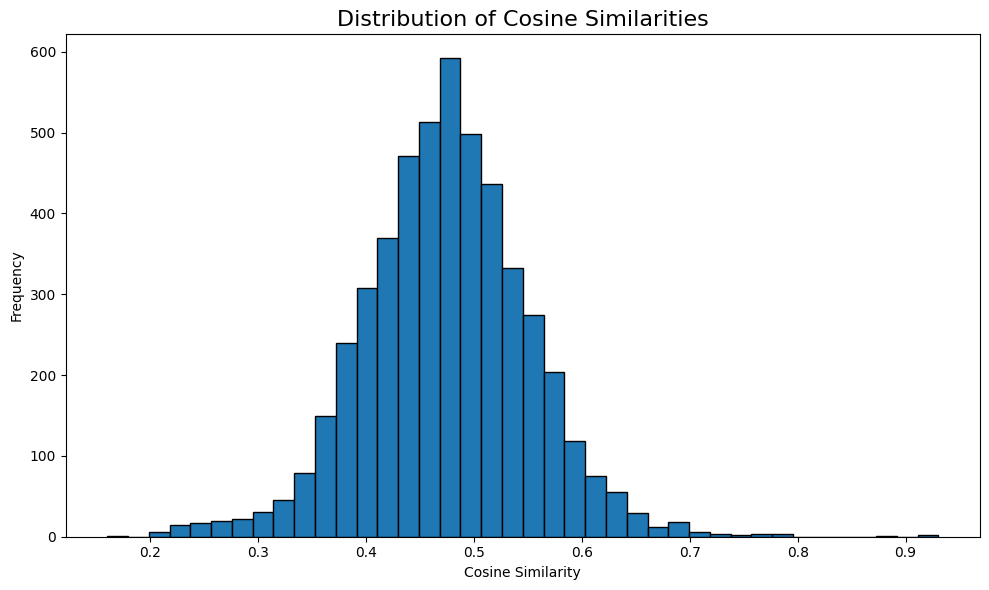

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    scores,
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of Cosine Similarities",
    fontsize=16
)

plt.xlabel("Cosine Similarity")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## 25. Most Similar Pair in Sample

In [32]:
matrix = similarity_matrix.copy()

np.fill_diagonal(
    matrix,
    -1
)

row, col = np.unravel_index(
    np.argmax(matrix),
    matrix.shape
)

print("Headline 1:\n")
print(sample_df.loc[row, "headline"])

print("\n")

print("Headline 2:\n")
print(sample_df.loc[col, "headline"])

print("\nSimilarity:", matrix[row, col])

Headline 1:

Stocks Hitting 52-Week Highs


Headline 2:

Stocks That Hit 52-Week Highs On Thursday

Similarity: 0.9304018


## 26. Save Similarity Matrix

In [33]:
np.save(

    os.path.join(

        EMBEDDING_PATH,

        "sample_similarity_matrix.npy"

    ),

    similarity_matrix

)

## 27. Save Similar News Results

In [34]:
similar_news = []

for i in range(len(sample_df)):

    scores = similarity_matrix[i]

    indices = np.argsort(scores)[::-1][1:6]

    for idx in indices:

        similar_news.append({

            "query_news_id":
                sample_df.loc[i, "news_id"],

            "similar_news_id":
                sample_df.loc[idx, "news_id"],

            "similarity":
                float(scores[idx])

        })

In [35]:
similar_news_df = pd.DataFrame(
    similar_news
)

similar_news_df.head()

,query_news_id,similar_news_id,similarity
0,66764,496045,0.652893
1,66764,1377300,0.647586
2,66764,377278,0.629755
3,66764,1349845,0.628410
4,66764,1088891,0.612061


In [36]:
similar_news_df.to_parquet(

    os.path.join(

        EMBEDDING_PATH,

        "sample_similar_news.parquet"

    ),

    index=False

)

## 28. Convert Embeddings to float32

In [37]:
embeddings = embeddings.astype(np.float32)

## 29. Create FAISS Index

In [38]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(
    dimension
)

## 30. Add Embeddings

In [39]:
index.add(
    embeddings
)

## 31. Verify Index

In [40]:
print("Embedding Dimension :", index.d)

print("Number of Vectors :", index.ntotal)

Embedding Dimension : 768
Number of Vectors : 100


## 32. Search Function

In [41]:
def semantic_search(
    query,
    top_k=5
):

    query_embedding = embedding_model.encode(

        [query],

        convert_to_numpy=True,

        normalize_embeddings=True

    ).astype(np.float32)

    scores, indices = index.search(

        query_embedding,

        top_k

    )

    results = sample_df.loc[
        indices[0],
        [
            "news_id",
            "headline",
            "ticker",
            "published_date"
        ]
    ].copy()

    results["similarity"] = scores[0]

    return results

## 33. Test Semantic Search

In [42]:
semantic_search(

    "Apple reports strong quarterly earnings",

    top_k=5

)

,news_id,headline,ticker,published_date,similarity
40,463532,Eagle Materials Earlier Reported Q2 Adj. EPS $...,EXP,2019-10-31 00:00:00+00:00,0.592257
22,3089212,"EMC profit tops, shares surge",VMW,2012-01-24 00:00:00+00:00,0.591081
51,2076895,Greenhill & Co. Reports Fourth Quarter Earning...,GHL,2020-02-04 00:00:00+00:00,0.587416
58,1651009,"Cathay General Bancorp EPS beats by $0.03, bea...",CATY,2019-07-17 00:00:00+00:00,0.580552
31,442219,The Week Ahead In Biotech: Pharma Earnings Pic...,EW,2019-07-20 00:00:00+00:00,0.575866


## 34. Another Query

In [43]:
semantic_search(

    "Tesla stock jumps after earnings",

    top_k=5

)

,news_id,headline,ticker,published_date,similarity
22,3089212,"EMC profit tops, shares surge",VMW,2012-01-24 00:00:00+00:00,0.690970
56,2150082,Cloud stocks see green after Cloudera earnings,HDP,2018-12-06 00:00:00+00:00,0.611249
58,1651009,"Cathay General Bancorp EPS beats by $0.03, bea...",CATY,2019-07-17 00:00:00+00:00,0.589500
91,496045,Option Alert: FLR Aug16 50.0 Calls: 500 @ ASK ...,FLR,2016-06-27 00:00:00+00:00,0.588999
31,442219,The Week Ahead In Biotech: Pharma Earnings Pic...,EW,2019-07-20 00:00:00+00:00,0.586245


## 35. Another Query

In [44]:
semantic_search(

    "Federal Reserve raises interest rates",

    top_k=5

)

,news_id,headline,ticker,published_date,similarity
71,272384,KBW Upgrades Capital One Financial to Outperfo...,COF,2011-07-07 00:00:00+00:00,0.550620
90,2287133,Markets Catch Collective Breath As Dollar Cons...,JEM,2019-11-06 00:00:00+00:00,0.537156
30,1352319,Benzinga's Top Pre-Market Gainers,WSM,2012-08-22 00:00:00+00:00,0.511779
91,496045,Option Alert: FLR Aug16 50.0 Calls: 500 @ ASK ...,FLR,2016-06-27 00:00:00+00:00,0.508247
15,2860105,Silver – The Bull Market Ahead,SLV,2019-08-25 00:00:00+00:00,0.502516


## 36. Save FAISS Index

In [45]:
faiss.write_index(

    index,

    os.path.join(

        EMBEDDING_PATH,

        "sample_faiss.index"

    )

)

## 37. Reload Test

In [46]:
loaded_index = faiss.read_index(

    os.path.join(

        EMBEDDING_PATH,

        "sample_faiss.index"

    )

)

print(

    loaded_index.ntotal

)

100


## 38. Compare FAISS vs Cosine Search

In [47]:
query = sample_df.loc[0, "headline"]

print("Query:\n")

print(query)

print("\n")

semantic_search(
    query,
    top_k=5
)

Query:

Antero Midstream shares are trading lower after the company reported a ~25.965 million share common stock offering. Wells Fargo also downgraded the stock from Outperform to Market Perform and lowered the price target from $10 to $8 per share.




,news_id,headline,ticker,published_date,similarity
0,66764,Antero Midstream shares are trading lower afte...,AM,2019-11-07 00:00:00+00:00,1.000000
91,496045,Option Alert: FLR Aug16 50.0 Calls: 500 @ ASK ...,FLR,2016-06-27 00:00:00+00:00,0.652892
76,1377300,Xerox Corporation Lowers FY2014 EPS Guidance f...,XRX,2014-04-22 00:00:00+00:00,0.647586
8,377278,"Benzinga's Top Upgrades, Downgrades For Februa...",DRQ,2019-02-20 00:00:00+00:00,0.629755
9,1349845,Benzinga's Top Downgrades,WPZ,2013-06-18 00:00:00+00:00,0.628411


## 39. Reduce Embeddings to 2D (UMAP)

In [48]:
reducer = umap.UMAP(

    n_neighbors=15,

    min_dist=0.1,

    metric="cosine",

    random_state=42

)

embedding_2d = reducer.fit_transform(
    embeddings
)

In [49]:
print(embedding_2d.shape)

(100, 2)


## 40. Add Coordinates

In [50]:
sample_df["x"] = embedding_2d[:, 0]

sample_df["y"] = embedding_2d[:, 1]

In [51]:
sample_df[
    [
        "headline",
        "x",
        "y"
    ]
].head()

,headline,x,y
0,Antero Midstream shares are trading lower afte...,3.238890,7.054744
1,Cnooc's Nexen cutting 340 jobs in North Americ...,4.102274,6.885778
2,Valuation Dashboard: Energy And Materials - Up...,5.127030,7.614907
3,China Faces Tough Decisions Ahead,2.575541,8.158178
4,Dividend Challenger Highlights: Week Of May 26,3.235729,9.719444


## 41. Plot Embedding Space

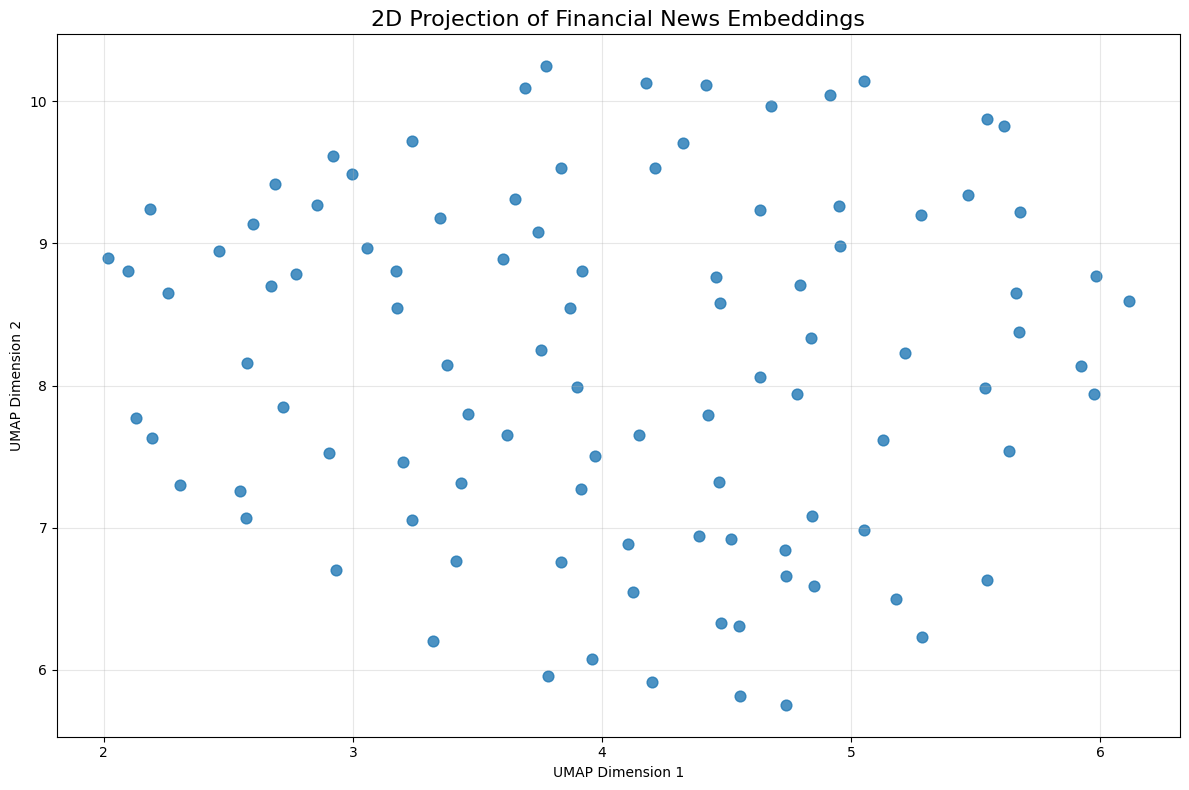

In [52]:
plt.figure(figsize=(12,8))

plt.scatter(

    sample_df["x"],

    sample_df["y"],

    s=60,

    alpha=0.8

)

plt.title(
    "2D Projection of Financial News Embeddings",
    fontsize=16
)

plt.xlabel("UMAP Dimension 1")

plt.ylabel("UMAP Dimension 2")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        REPORT_PATH,

        "embedding_space.png"

    ),

    dpi=300

)

plt.show()

## 42. Color by Source

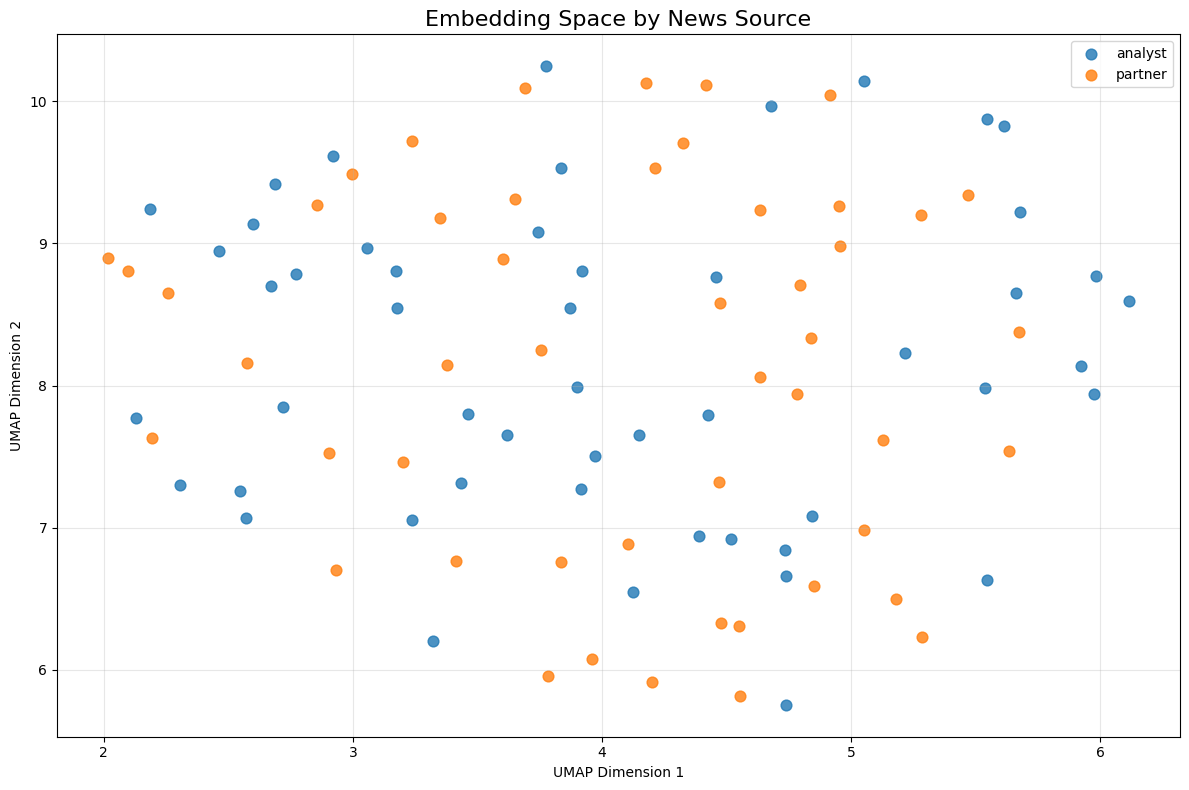

In [53]:
plt.figure(figsize=(12,8))

for source in sample_df["source"].unique():

    temp = sample_df[
        sample_df["source"] == source
    ]

    plt.scatter(

        temp["x"],

        temp["y"],

        s=60,

        label=source,

        alpha=0.8

    )

plt.legend()

plt.title(
    "Embedding Space by News Source",
    fontsize=16
)

plt.xlabel("UMAP Dimension 1")

plt.ylabel("UMAP Dimension 2")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        REPORT_PATH,

        "embedding_by_source.png"

    ),

    dpi=300

)

plt.show()

## 43. Color by Year

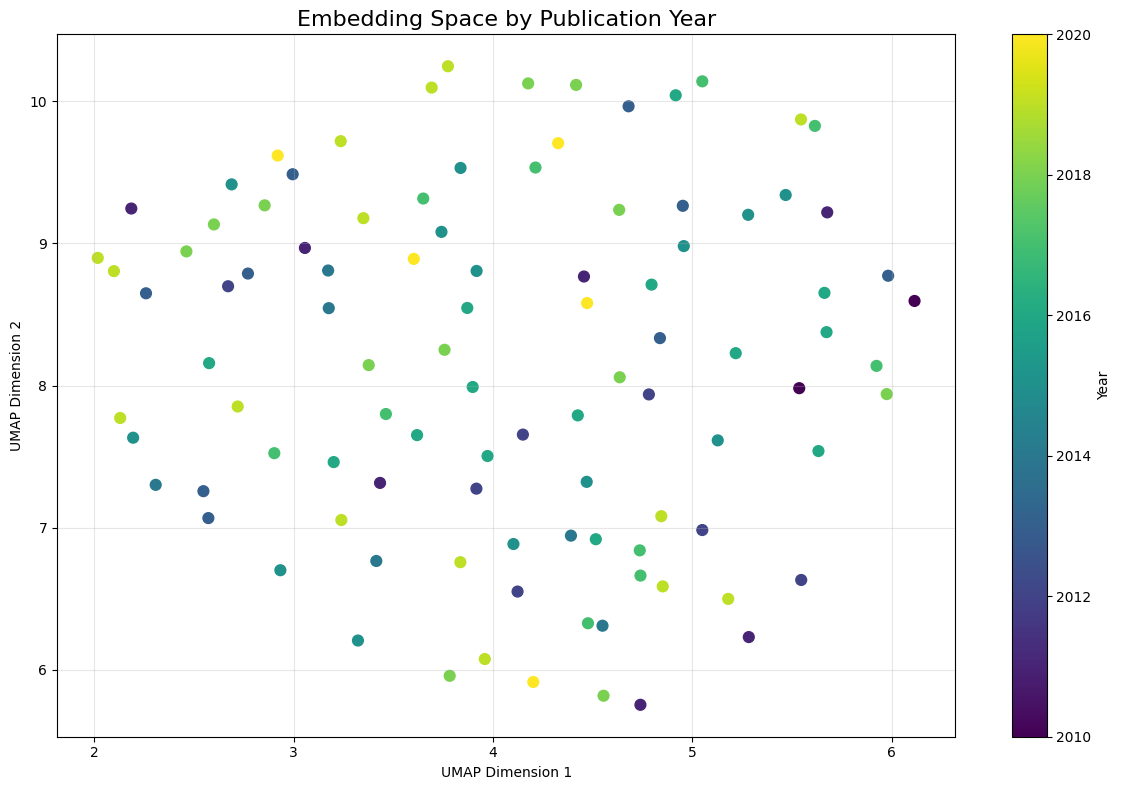

In [54]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(

    sample_df["x"],

    sample_df["y"],

    c=sample_df["year"],

    cmap="viridis",

    s=60

)

plt.colorbar(
    scatter,
    label="Year"
)

plt.title(
    "Embedding Space by Publication Year",
    fontsize=16
)

plt.xlabel("UMAP Dimension 1")

plt.ylabel("UMAP Dimension 2")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        REPORT_PATH,

        "embedding_by_year.png"

    ),

    dpi=300

)

plt.show()

## 44. Save UMAP Coordinates

In [55]:
sample_df.to_parquet(

    os.path.join(

        EMBEDDING_PATH,

        "sample_embedding_projection.parquet"

    ),

    index=False

)

## 45. Notebook Summary

In [56]:
summary = pd.DataFrame({

    "Metric":[

        "Sample Headlines",

        "Embedding Dimension",

        "FAISS Index Size",

        "Average Similarity",

        "Highest Similarity"

    ],

    "Value":[

        len(sample_df),

        embeddings.shape[1],

        index.ntotal,

        similarity_matrix.mean(),

        similarity_matrix.max()

    ]

})

summary

,Metric,Value
0,Sample Headlines,100.000000
1,Embedding Dimension,768.000000
2,FAISS Index Size,100.000000
3,Average Similarity,0.479522
4,Highest Similarity,1.000001
